### **INSTALACIÓN DE LIBRERÍAS**

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn tensorflow

### **IMPORTACIÓN DE MÓDULOS Y CONFIGURACIÓN DE VISUALIZACIÓN**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import time

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    RepeatVector,
    TimeDistributed,
    Dropout,
    Conv1D,
    MaxPooling1D,
    UpSampling1D,
    Bidirectional
)

from tensorflow.keras.callbacks import EarlyStopping

### **CARGA DEL DATASET HAI**

In [3]:
# =========================================================
# RUTAS
# =========================================================

train1_path = '/content/hai-train1.csv'
train2_path = '/content/hai-train2.csv'
train3_path = '/content/hai-train3.csv'
train4_path = '/content/hai-train4.csv'

test1_path = '/content/hai-test1.csv'
test2_path = '/content/hai-test2.csv'

label1_path = '/content/label-test1.csv'
label2_path = '/content/label-test2.csv'

# =========================================================
# CARGAR TRAIN
# =========================================================

train1 = pd.read_csv(train1_path)

train2 = pd.read_csv(train2_path)

train3 = pd.read_csv(train3_path)

train4 = pd.read_csv(train4_path)

# Unir todos los train
train_df = pd.concat(
    [train1, train2, train3, train4],
    ignore_index=True
)

print("TRAIN SHAPE:")
print(train_df.shape)

# =========================================================
# CARGAR TEST
# =========================================================

test1 = pd.read_csv(test1_path)

test2 = pd.read_csv(test2_path)

# Unir test
test_df = pd.concat(
    [test1, test2],
    ignore_index=True
)

print("\nTEST SHAPE:")
print(test_df.shape)

# =========================================================
# CARGAR LABELS
# =========================================================

label1 = pd.read_csv(label1_path)

label2 = pd.read_csv(label2_path)

# Unir labels
label_df = pd.concat(
    [label1, label2],
    ignore_index=True
)

print("\nLABEL SHAPE:")
print(label_df.shape)

# =========================================================
# AGREGAR LABELS AL TEST
# =========================================================

test_df['label'] = label_df['label']

# =========================================================
# DISTRIBUCIÓN DE CLASES
# =========================================================

print("\nDistribución de clases:")
print(test_df['label'].value_counts())


TRAIN SHAPE:
(896400, 87)

TEST SHAPE:
(284400, 87)

LABEL SHAPE:
(284400, 2)

Distribución de clases:
label
0    273016
1     11384
Name: count, dtype: int64


### **DISTRIBUCIÓN DE CLASES**

/tmp/ipykernel_523/346778080.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


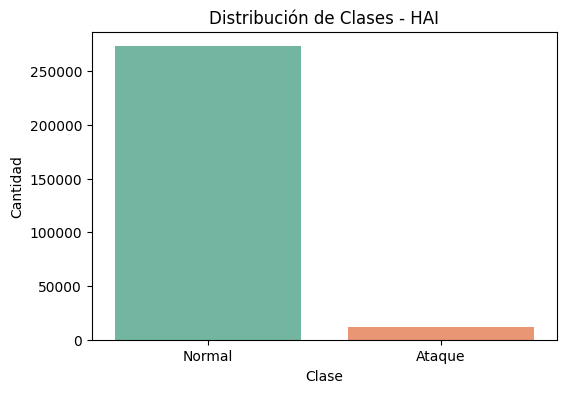

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=test_df['label'],
    palette='Set2'
)

plt.title('Distribución de Clases - HAI')

plt.xlabel('Clase')
plt.ylabel('Cantidad')

plt.xticks(
    [0,1],
    ['Normal', 'Ataque']
)

plt.show()

### **PREPROCESAMIENTO TRAIN**

In [24]:
# =========================================================
# TRAIN
# =========================================================

X_train = train_df.copy()

# Eliminar columnas irrelevantes
possible_drop = ['timestamp', 'time', 'date', 'source_file']

for col in possible_drop:

    cols = [
        c for c in X_train.columns
        if col in c.lower()
    ]

    X_train = X_train.drop(
        columns=cols,
        errors='ignore'
    )

# Solo numéricas
X_train = X_train.select_dtypes(include=[np.number])

print(f'Variables train: {X_train.shape[1]}')


# Diferencias temporales
for col in X_train.columns[:10]:

    X_train[f'{col}_diff'] = (
        X_train[col]
        .diff()
        .fillna(0)
    )

# Media móvil
for col in X_train.columns[:5]:

    X_train[f'{col}_rolling_mean'] = (
        X_train[col]
        .rolling(window=3)
        .mean()
        .fillna(0)
    )

# Desviación estándar móvil
for col in X_train.columns[:5]:

    X_train[f'{col}_rolling_std'] = (
        X_train[col]
        .rolling(window=3)
        .std()
        .fillna(0)
    )

print(f'Nuevas dimensiones train: {X_train.shape}')

Variables train: 86
Nuevas dimensiones train: (896400, 106)


### **PREPROCESAMIENTO TEST**

In [25]:
# =========================================================
# TEST
# =========================================================

X_test = test_df.drop(columns=['label'])

y_test = test_df['label']

# Eliminar columnas irrelevantes
for col in possible_drop:

    cols = [
        c for c in X_test.columns
        if col in c.lower()
    ]

    X_test = X_test.drop(
        columns=cols,
        errors='ignore'
    )

# Solo numéricas
X_test = X_test.select_dtypes(include=[np.number])


# Diferencias temporales
for col in X_test.columns[:10]:

    X_test[f'{col}_diff'] = (
        X_test[col]
        .diff()
        .fillna(0)
    )

# Media móvil
for col in X_test.columns[:5]:

    X_test[f'{col}_rolling_mean'] = (
        X_test[col]
        .rolling(window=3)
        .mean()
        .fillna(0)
    )

# Desviación estándar móvil
for col in X_test.columns[:5]:

    X_test[f'{col}_rolling_std'] = (
        X_test[col]
        .rolling(window=3)
        .std()
        .fillna(0)
    )

print(f'Nuevas dimensiones test: {X_test.shape}')

Nuevas dimensiones test: (284400, 106)


### **NORMALIZACIÓN Y ESCALAMIENTO**

In [26]:
# =========================================================
# IMPUTAR VALORES FALTANTES
# =========================================================

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# =========================================================
# ESCALADO
# =========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

# =========================================================
# REDUCIR TAMAÑO PARA COLAB
# =========================================================

MAX_SAMPLES = 200000

X_train = X_train[:MAX_SAMPLES]

X_test = X_test[:50000]
y_test = y_test.iloc[:50000].reset_index(drop=True)

print(X_train.shape)
print(X_test.shape)
print(y_test.shape)

Train shape: (896400, 106)
Test shape: (284400, 106)
(200000, 106)
(50000, 106)
(50000,)


### **CREAR VENTANAS TEMPORALES**

In [27]:
# =========================================================
# CREAR VENTANAS TEMPORALES
# =========================================================

TIMESTEPS = 5

def create_sequences(data, time_steps=5):

    sequences = []

    for i in range(len(data) - time_steps):

        seq = data[i:(i + time_steps)]

        sequences.append(seq)

    return np.array(sequences)

X_train_seq = create_sequences(X_train, TIMESTEPS)

X_test_seq = create_sequences(X_test, TIMESTEPS)

# Ajustar labels
y_test_seq = y_test[TIMESTEPS:].values

print("Train sequences:", X_train_seq.shape)
print("Test sequences:", X_test_seq.shape)

Train sequences: (199995, 5, 106)
Test sequences: (49995, 5, 106)


### **ENTRENAMIENTO LSTM AUTOENCODER**

In [30]:
print("\n" + "="*60)
print("ENTRENAMIENTO Y EVALUACIÓN: LSTM-AE + CNN")
print("="*60)
print("\n")

# =========================================================
# MODELO CNN + BiLSTM AUTOENCODER
# =========================================================
model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same',
           input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    Bidirectional(LSTM(64, activation='tanh', return_sequences=False)),
    Dropout(0.2),
    RepeatVector(X_train_seq.shape[1]),
    Bidirectional(LSTM(64, activation='tanh', return_sequences=True)),
    Dropout(0.2),
    TimeDistributed(Dense(X_train_seq.shape[2]))
])

model.compile(optimizer='adam', loss='mae')

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# =========================================================
# 1. ENTRENAMIENTO
# =========================================================
print("Iniciando entrenamiento LSTM...")
start_train = time.time()

history = model.fit(
    X_train_seq, X_train_seq,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)

end_train = time.time()
tiempo_entrenamiento = end_train - start_train


ENTRENAMIENTO Y EVALUACIÓN: LSTM-AE + CNN


Iniciando entrenamiento LSTM...
Epoch 1/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 72s 24ms/step - loss: 0.3751 - val_loss: 0.4234
Epoch 2/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 57s 20ms/step - loss: 0.3256 - val_loss: 0.3608
Epoch 3/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 58s 21ms/step - loss: 0.3104 - val_loss: 0.3370
Epoch 4/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 57s 20ms/step - loss: 0.3000 - val_loss: 0.3358
Epoch 5/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 57s 20ms/step - loss: 0.2926 - val_loss: 0.3356
Epoch 6/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 57s 20ms/step - loss: 0.2901 - val_loss: 0.3290
Epoch 7/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 57s 20ms/step - loss: 0.2838 - val_loss: 0.3247
Epoch 8/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 83s 21ms/step - loss: 0.2793 - val_loss: 0.3163
Epoch 9/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 63s 22ms/step - loss: 0.2717 - val_loss: 0.3026
Epoch 10/10
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 76s 20ms/step - loss: 0.2675 - val_loss: 0.3025


### **DETECCIÓN DE ANOMALIAS**

In [31]:
# =========================================================
# 2. PREDICCIÓN / INFERENCIA
# =========================================================
print("\nIniciando inferencia sobre conjunto de prueba...")
start_infer = time.time()

X_test_pred = model.predict(X_test_seq)

end_infer = time.time()
tiempo_inferencia = end_infer - start_infer

# Calculamos la velocidad
num_registros = X_test_seq.shape[0]
velocidad_deteccion = tiempo_inferencia / num_registros

# =========================================================
# 3. DTAM (Dynamic Threshold)
# =========================================================
# Reconstruction Error
mse = np.mean(np.power(X_test_seq - X_test_pred, 2), axis=(1,2))

mean_error = np.mean(mse)
std_error = np.std(mse)

threshold = mean_error + (0.01 * std_error)

# Predicciones finales
y_pred_lstm = (mse > threshold).astype(int)


Iniciando inferencia sobre conjunto de prueba...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step


### **MÉTRICAS**

In [35]:
# =========================================================
# EVALUACIÓN DEL MODELO LSTM-AE + CNN
# =========================================================

print("\n" + "="*60)
print("RESULTADOS DEL MODELO: LSTM-AE + CNN")
print("="*60)

# =========================================================
# VARIABLES REALES Y PREDICHAS
# =========================================================

y_true = y_test_seq
y_pred = y_pred_lstm

# =========================================================
# MÉTRICAS PRINCIPALES
# =========================================================

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

# ROC-AUC
roc_auc = roc_auc_score(
    y_true,
    mse
)

# =========================================================
# MATRIZ DE CONFUSIÓN
# =========================================================

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

# =========================================================
# MÉTRICAS DE FIABILIDAD
# =========================================================

fpr_value = fp / (fp + tn)
fnr_value = fn / (fn + tp)

# =========================================================
# IMPRESIÓN DE RESULTADOS
# =========================================================

print("\n[ MÉTRICAS DE CLASIFICACIÓN ]")
print("-" * 40)

print(f"Accuracy                : {accuracy:.4f}")
print(f"Precision               : {precision:.4f}")
print(f"Recall                  : {recall:.4f}")
print(f"F1-Score                : {f1:.4f}")
print(f"ROC-AUC                 : {roc_auc:.4f}")

print("\n[ RENDIMIENTO COMPUTACIONAL ]")
print("-" * 40)

print(f"Tiempo de entrenamiento : {tiempo_entrenamiento:.2f} s")
print(f"Tiempo de inferencia    : {tiempo_inferencia:.2f} s")
print(f"Velocidad por registro  : {velocidad_deteccion:.6f} s")

print("\n[ FIABILIDAD DE DETECCIÓN ]")
print("-" * 40)

print(f"False Positive Rate     : {fpr_value:.4f} ({fpr_value*100:.2f}%)")
print(f"False Negative Rate     : {fnr_value:.4f} ({fnr_value*100:.2f}%)")

print("\n[ REPORTE DE CLASIFICACIÓN ]")
print("-" * 40)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=['Normal', 'Ataque'],
        digits=4
    )
)

print("="*60)


RESULTADOS DEL MODELO: LSTM-AE + CNN

[ MÉTRICAS DE CLASIFICACIÓN ]
----------------------------------------
Accuracy                : 0.9143
Precision               : 0.3649
Recall                  : 0.5914
F1-Score                : 0.4514
ROC-AUC                 : 0.8143

[ RENDIMIENTO COMPUTACIONAL ]
----------------------------------------
Tiempo de entrenamiento : 640.29 s
Tiempo de inferencia    : 9.83 s
Velocidad por registro  : 0.000197 s

[ FIABILIDAD DE DETECCIÓN ]
----------------------------------------
False Positive Rate     : 0.0653 (6.53%)
False Negative Rate     : 0.4086 (40.86%)

[ REPORTE DE CLASIFICACIÓN ]
----------------------------------------
              precision    recall  f1-score   support

      Normal     0.9730    0.9347    0.9535     47014
      Ataque     0.3649    0.5914    0.4514      2981

    accuracy                         0.9143     49995
   macro avg     0.6690    0.7631    0.7024     49995
weighted avg     0.9368    0.9143    0.9236     4999

### **MATRIZ DE CONFUSIÓN**

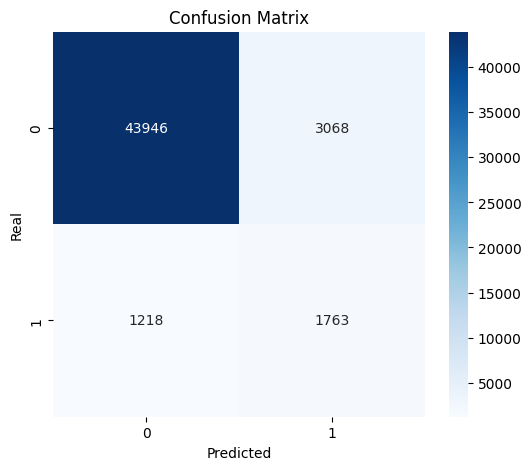

In [33]:
# =========================================================
# MATRIZ DE CONFUSIÓN
# =========================================================

cm = confusion_matrix(
    y_test_seq,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Real')

plt.show()

### **ROC Y AUC**

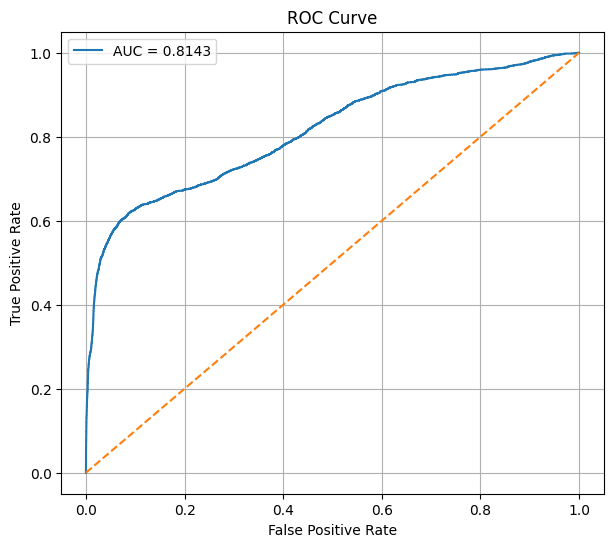

ROC-AUC Score: 0.8143


In [34]:
# =========================================================
# CURVA ROC Y AUC
# =========================================================

roc_fpr, roc_tpr, thresholds = roc_curve(
    y_test_seq,
    mse
)

auc_score = roc_auc_score(
    y_test_seq,
    mse
)

# Gráfico ROC
plt.figure(figsize=(7,6))

plt.plot(
    roc_fpr,
    roc_tpr,
    label=f'AUC = {auc_score:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.grid()

plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")